In [9]:
import matplotlib.pyplot as plt
import sys
import os

In [10]:
# Add the parent directory to the path to import src as a package
sys.path.insert(0, os.path.abspath('..'))
from src import dataloader
from src import utils
import importlib
importlib.reload(dataloader)

%matplotlib inline
plot_flag = False

# Load example data for one dyad

In [11]:
dyad_id = "W_030"
lowcut=1.0
highcut=40.0
eeg_filter_type = 'iir' # choose 'fir' or 'iir' for EEG filtering
q=8  # decimation factor
multimodal_data = dataloader.create_multimodal_data(data_base_path = "../data", 
                                                    dyad_id = dyad_id, 
                                                    load_eeg=True, 
                                                    load_et=True, 
                                                    lowcut=lowcut, 
                                                    highcut=highcut, 
                                                    eeg_filter_type=eeg_filter_type, 
                                                    interpolate_et_during_blinks_threshold=0.3,
                                                    median_filter_size=64,
                                                    low_pass_et_order=351,
                                                    et_pos_cutoff=128,
                                                    et_pupil_cutoff=4,
                                                    pupil_model_confidence=0.9,
                                                    decimate_factor=q,
                                                    plot_flag=plot_flag)

Detected events: {'Brave': {'name': 'Brave', 'start': 387.806640625, 'duration': 59.3310546875}, 'Peppa': {'name': 'Peppa', 'start': 248.5107421875, 'duration': 59.6328125}, 'Incredibles': {'name': 'Incredibles', 'start': 318.3603515625, 'duration': 59.212890625}, 'Talk_1': {'name': 'Talk_1', 'start': 594.4892578125, 'duration': 181.0556640625}, 'Talk_2': {'name': 'Talk_2', 'start': 836.7275390625, 'duration': 181.056640625}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Peppa
ET time range: 241.59s to 461.89s
Events from ET annotations:
[None 'Peppa' 'Incredibles' 'Brave']
Reseting the ET time to the start of Peppa
Processing member: ch, blink column: ET_ch_blinks
Processing member: cg, blink column: ET_cg_blinks
Column ET_ch_blinks contains NaN values, applying forward and backward fill before decimation.
Column ET_cg_blinks contains NaN values, applying forward and backward fill before decimation.
Event Peppa start times are consistent within 0.0 seconds.
E

## Select data according to an event

Retrieved EEG data shape: (7633, 3)


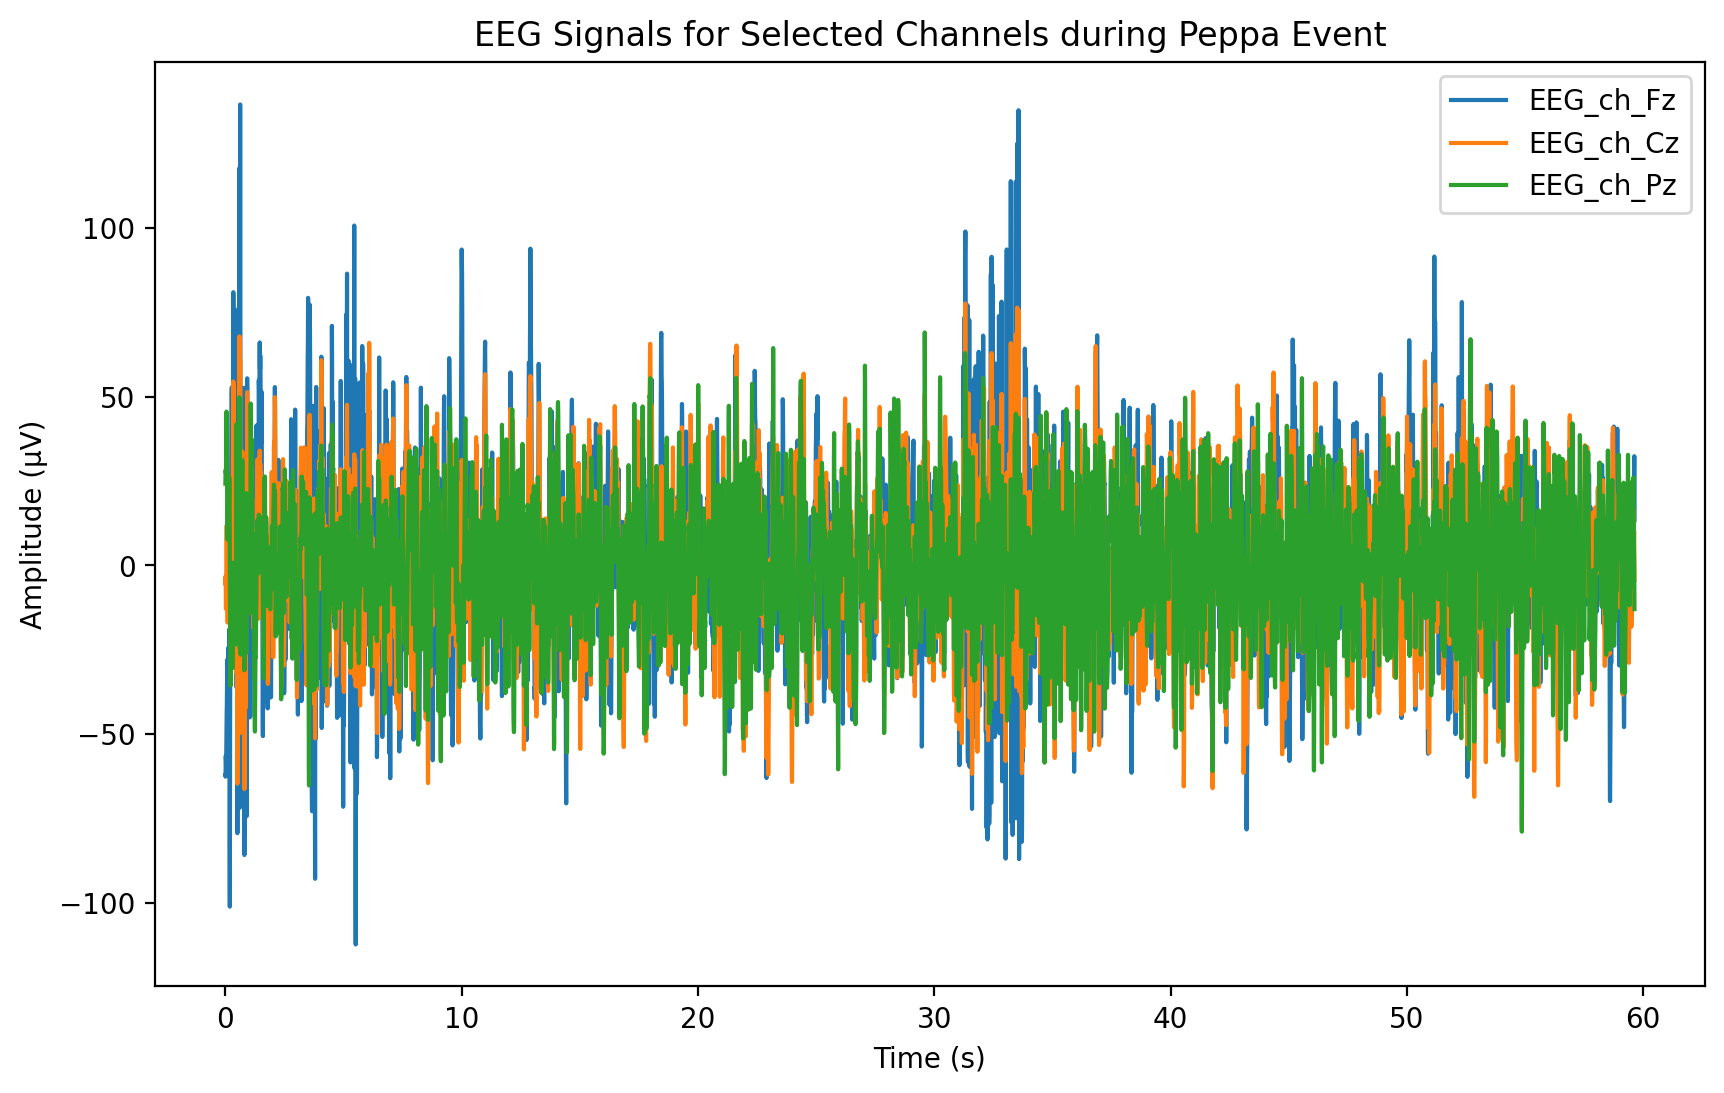

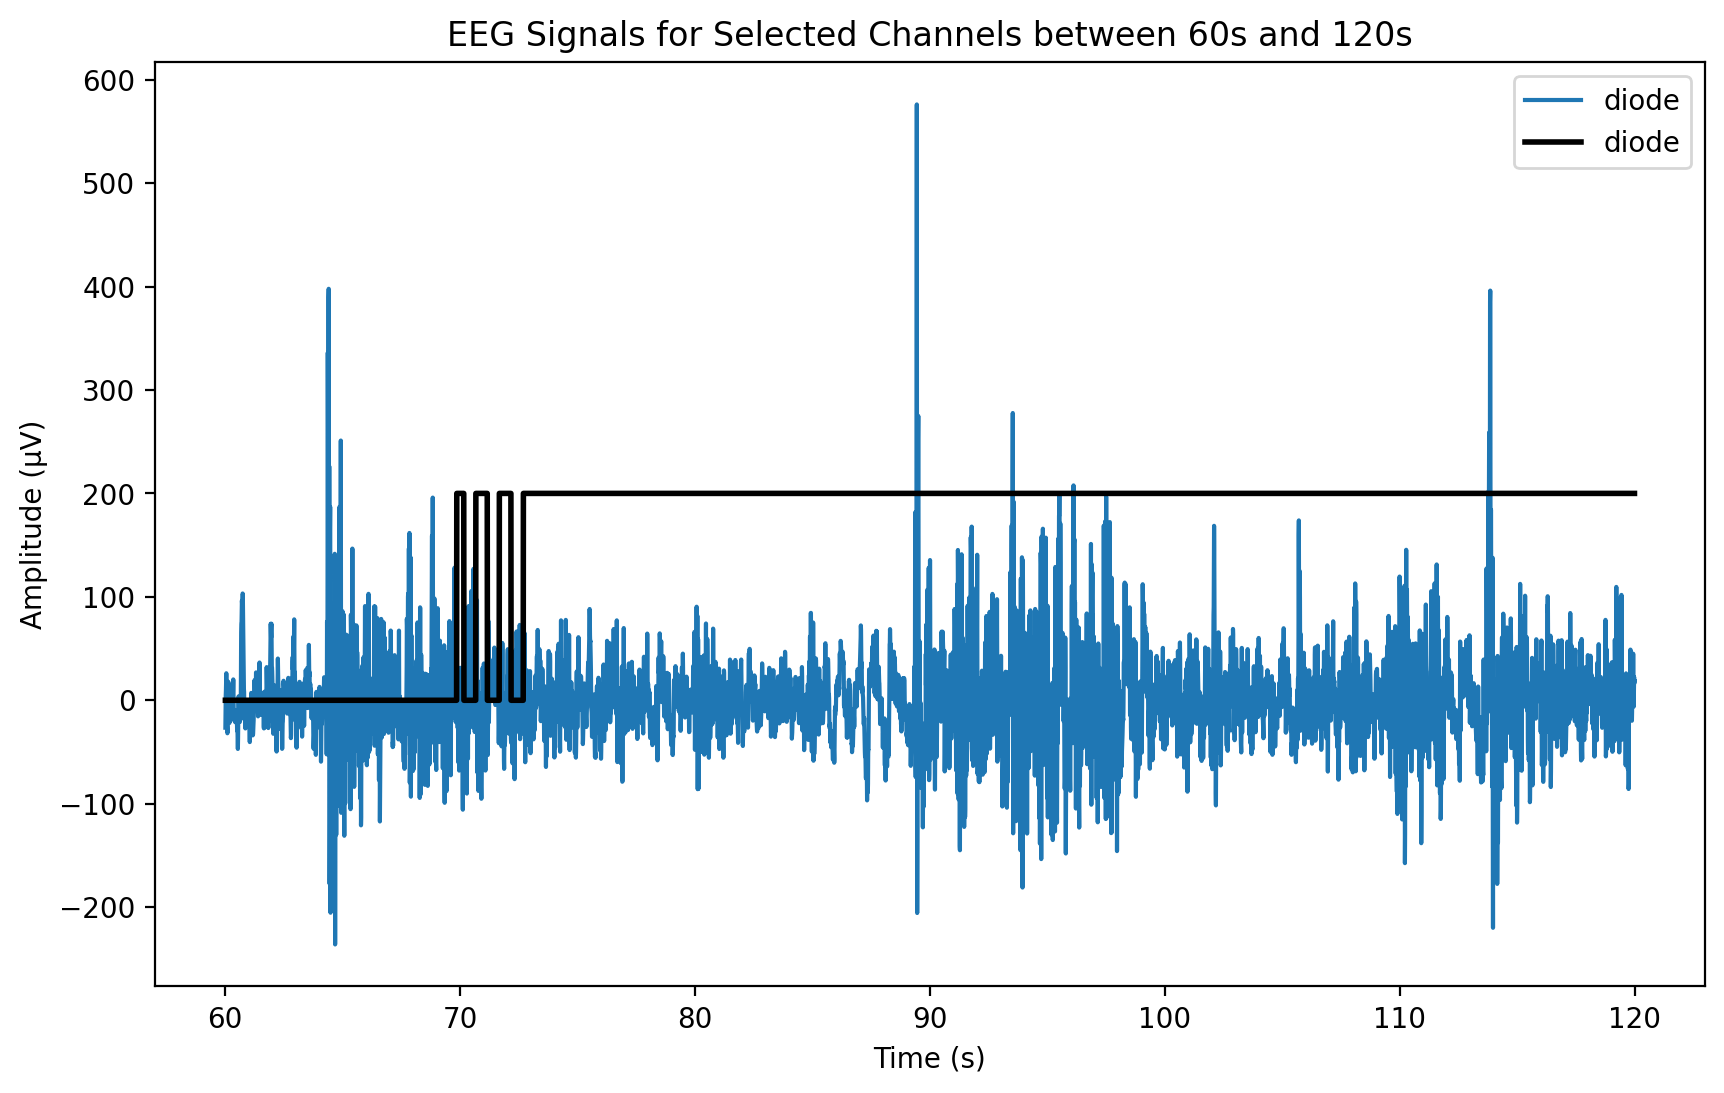

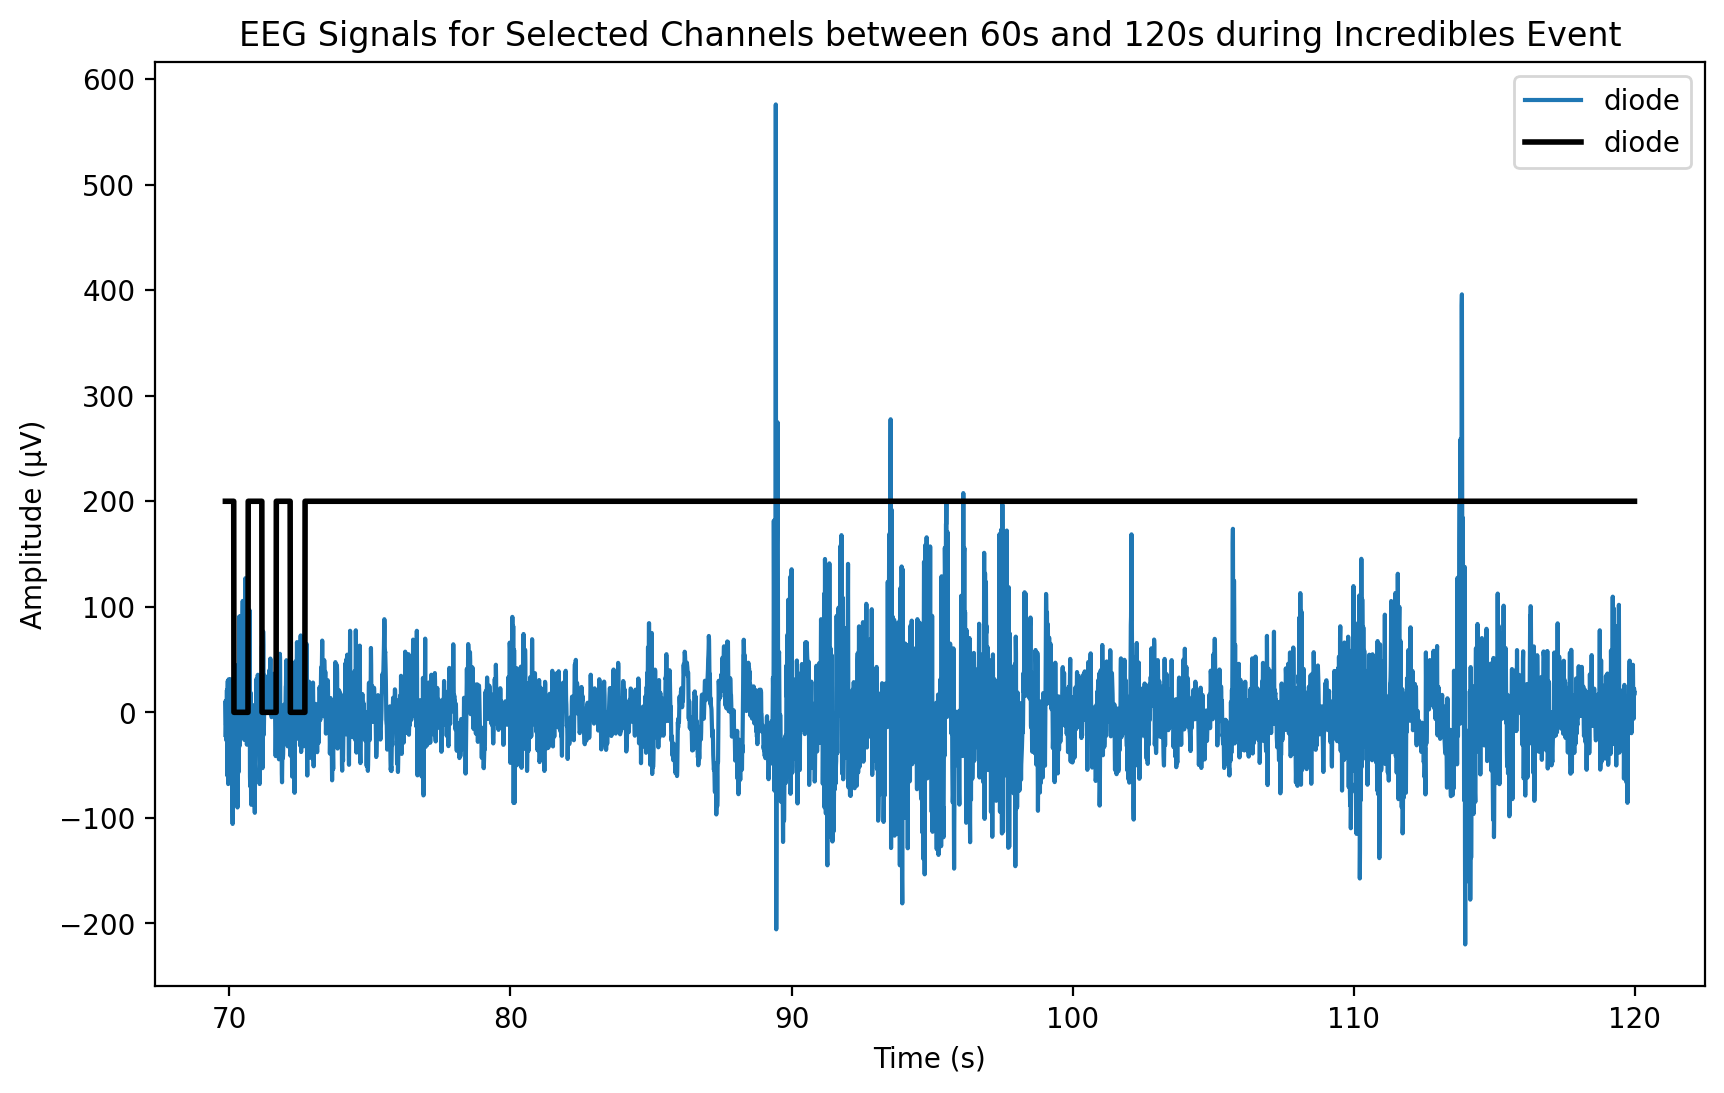

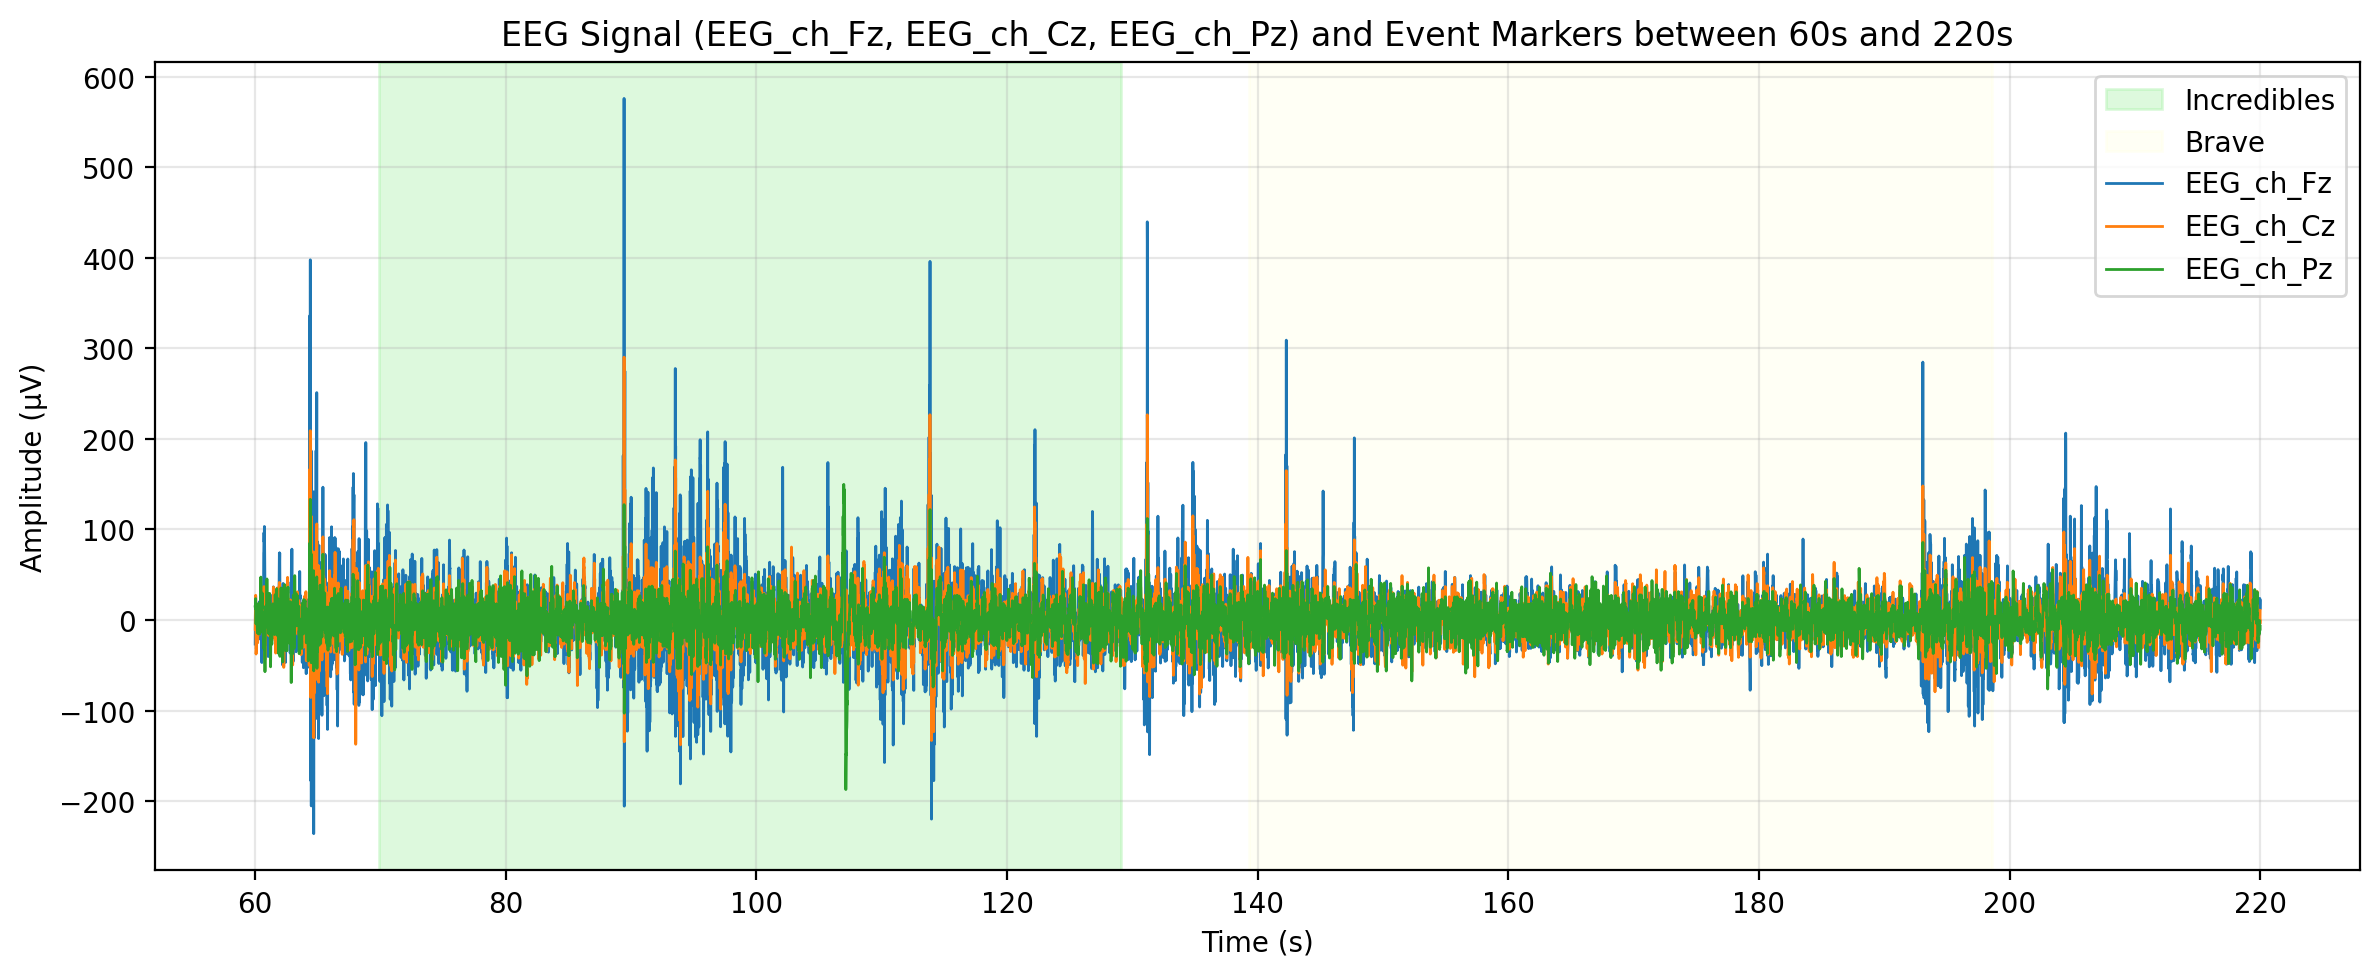

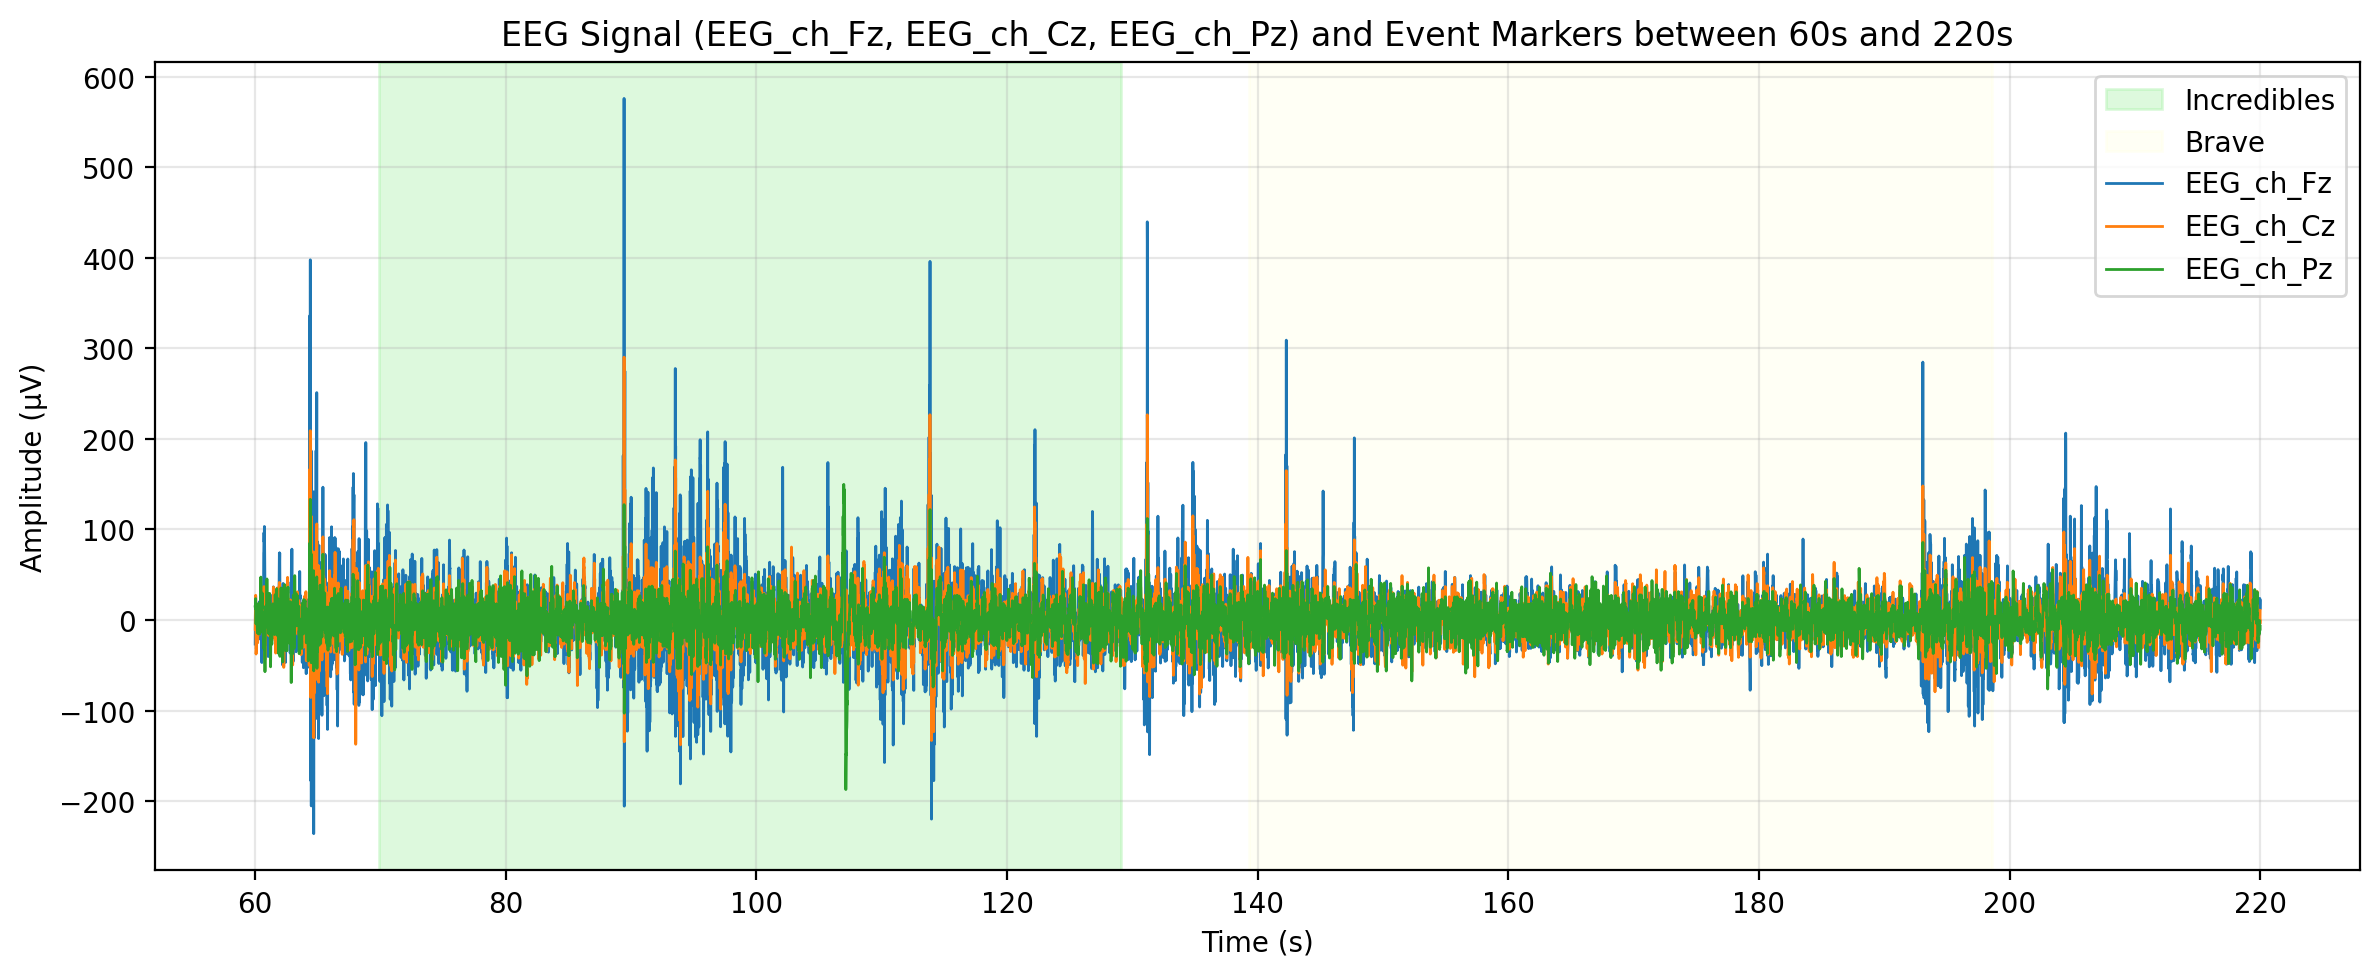

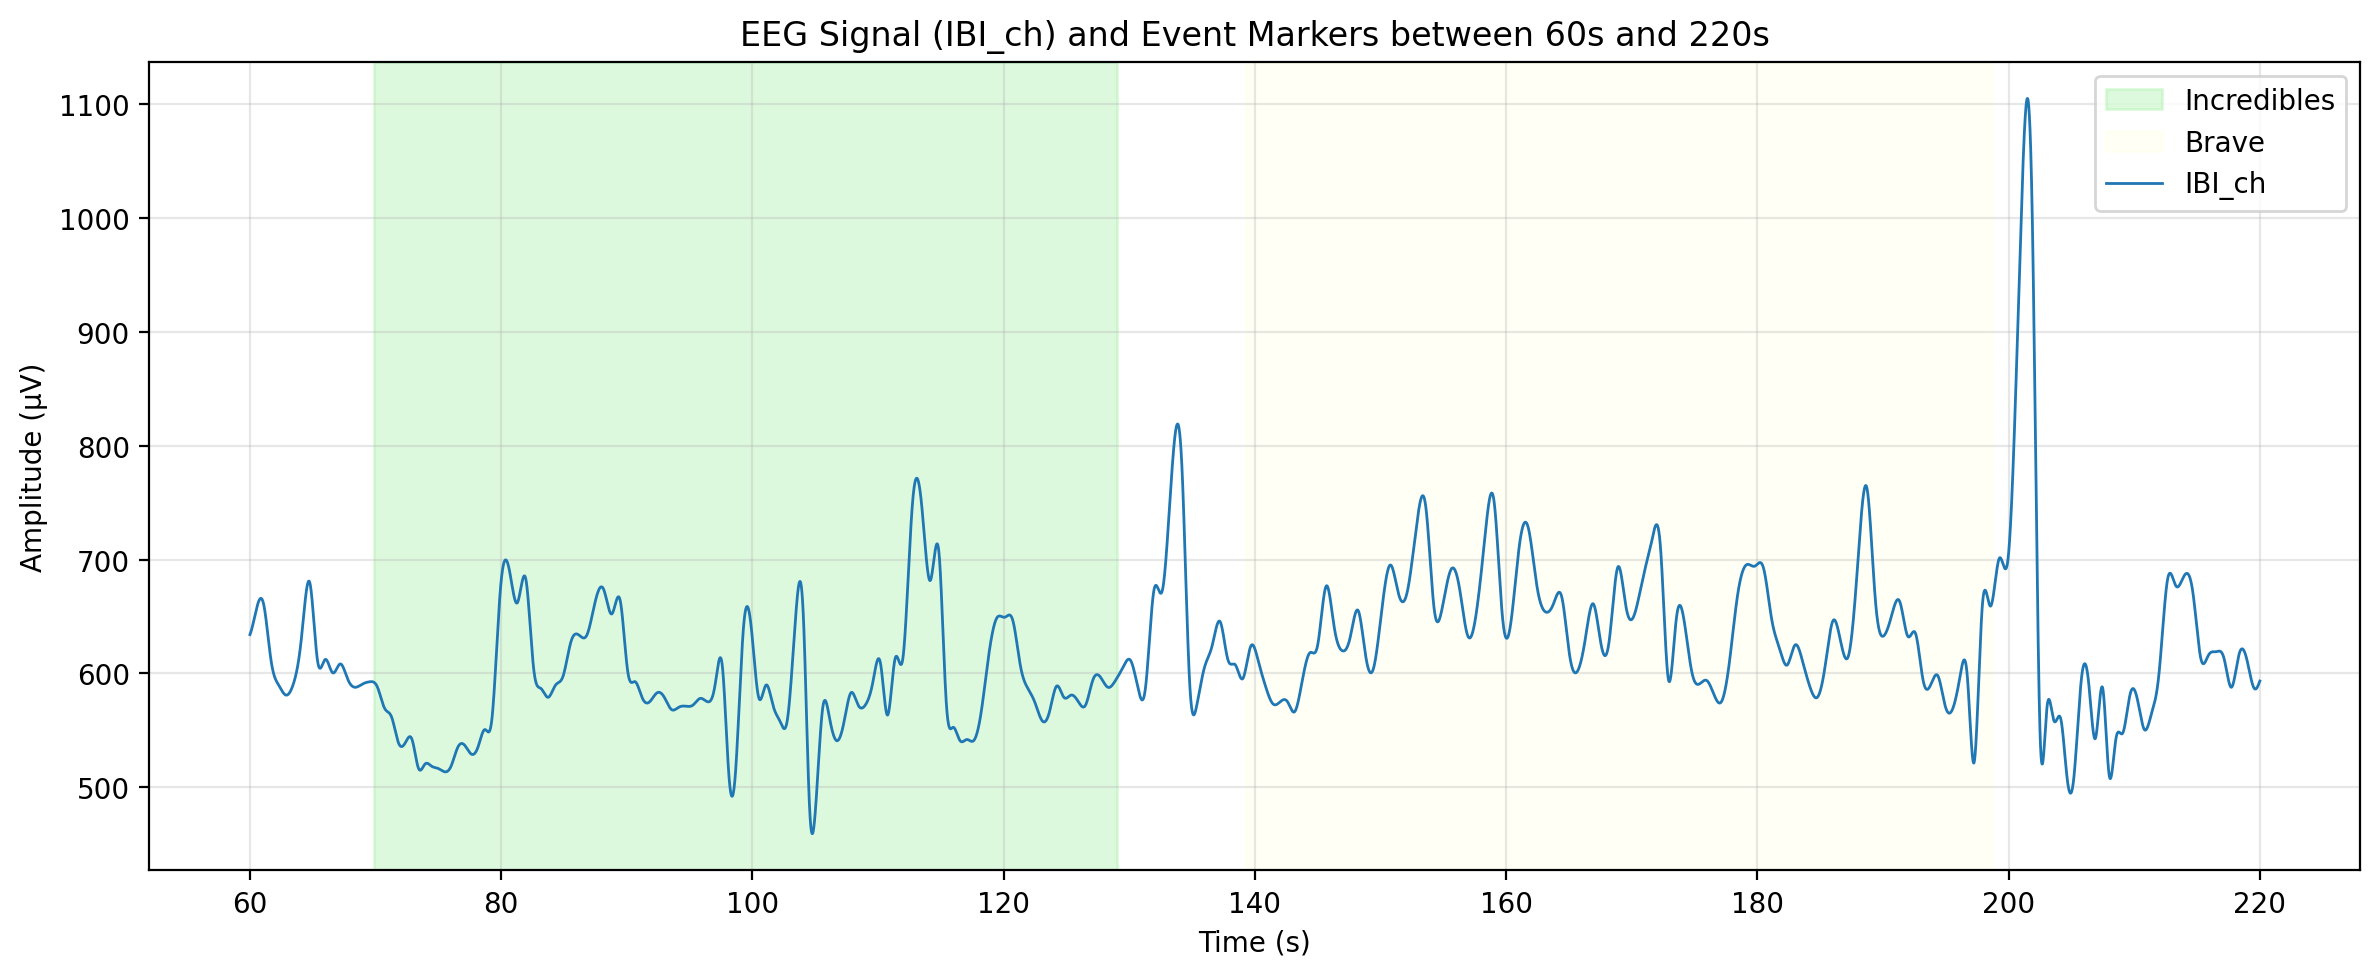

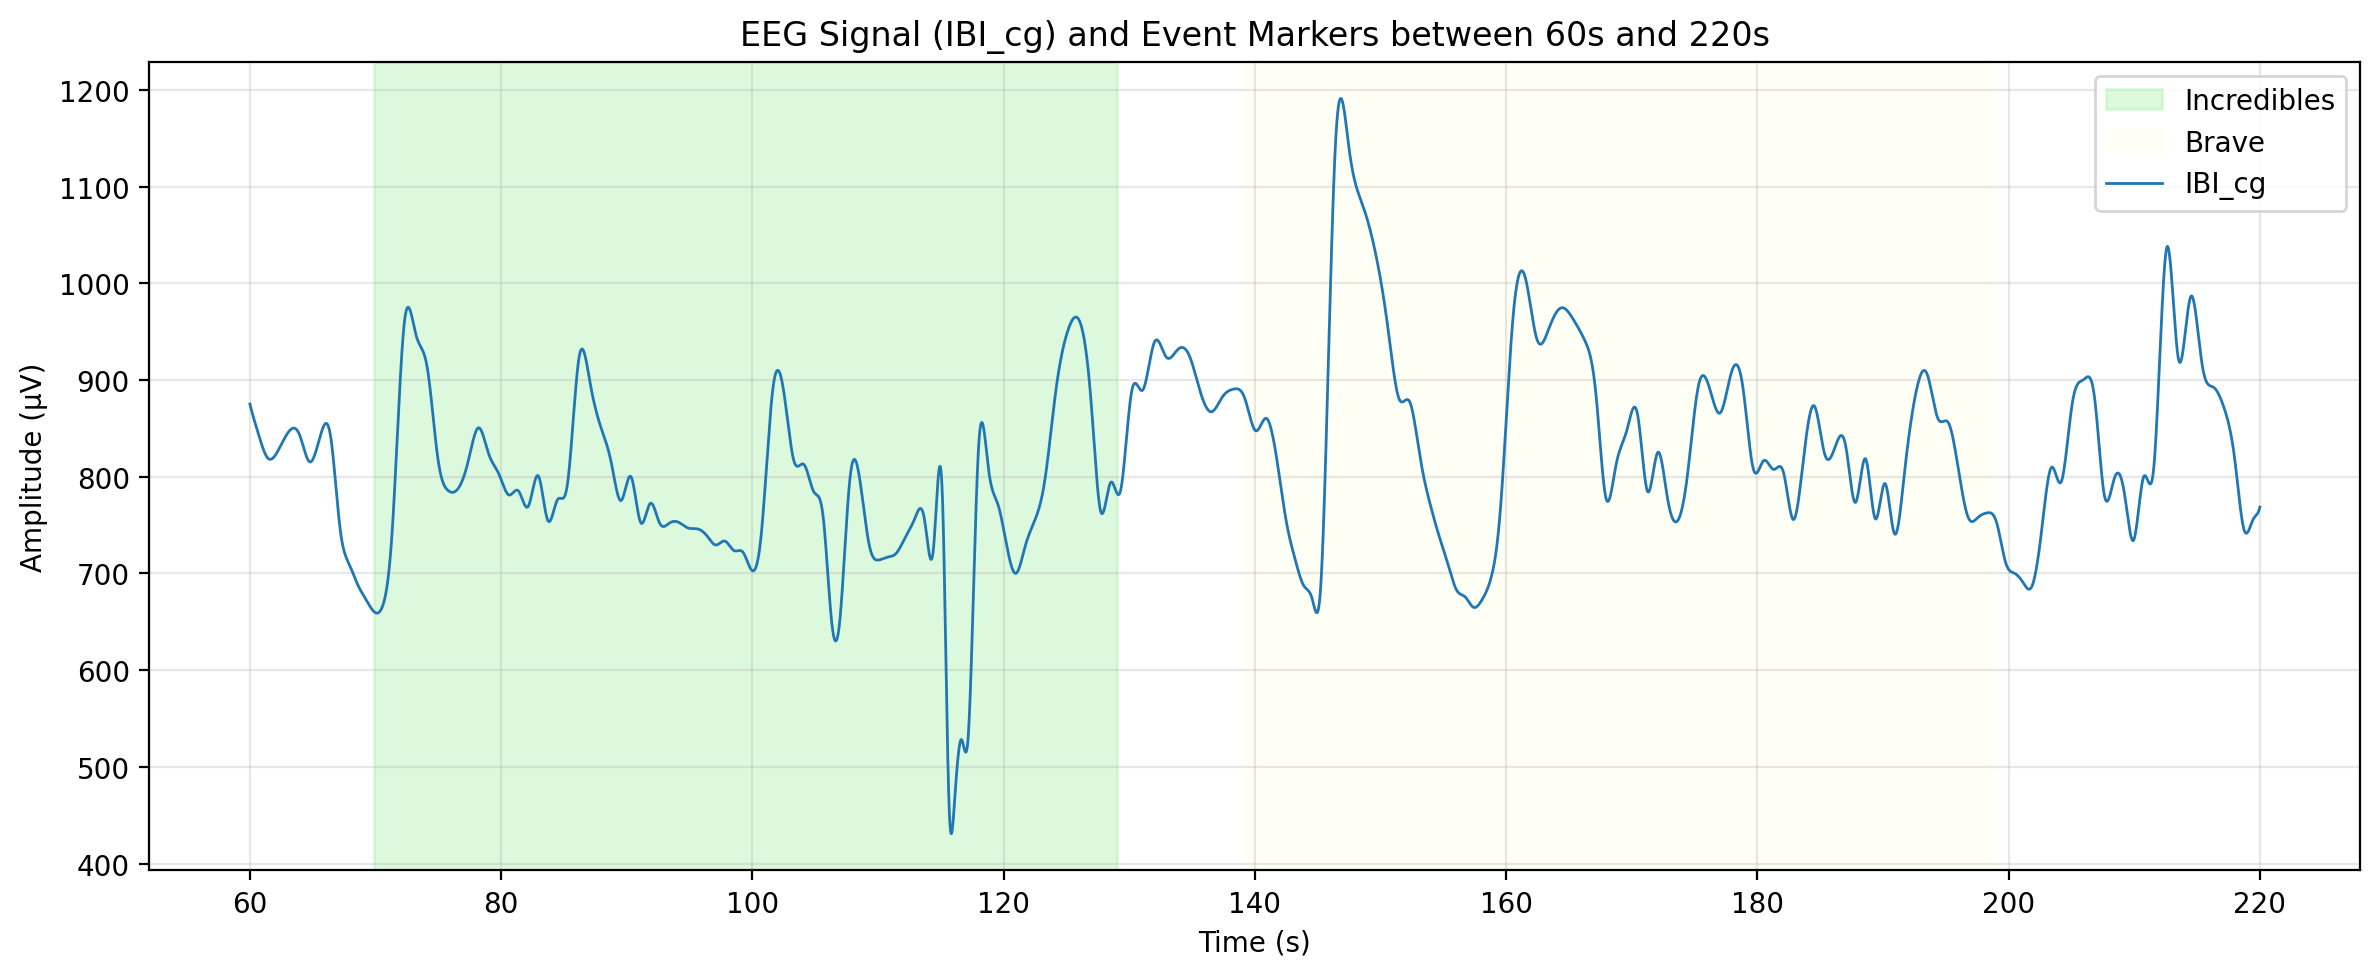

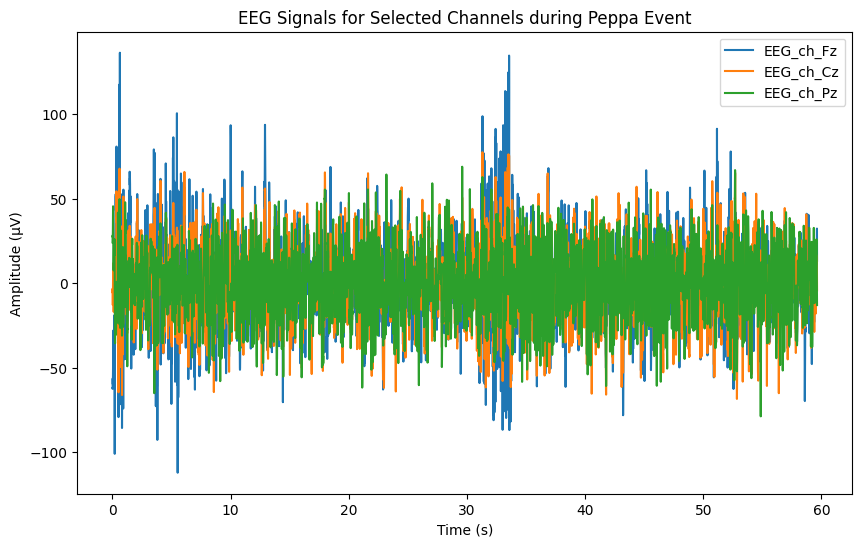

In [12]:
# Get selected child EEG channels for specific event

selected_event = 'Peppa' # 'Incredibles', 'Brave'
time, channels, data = multimodal_data.get_signals(
                mode='EEG', 
                member='ch', 
                selected_channels=['Fz', 'Cz', 'Pz'],
                selected_events=[selected_event]
            )
print(f"Retrieved EEG data shape: {data.shape}")  # Should be (n_channels, n_samples)
# Plot the retrieved EEG data
plt.figure(figsize=(10, 6))
for i, ch_name in enumerate(channels):
    plt.plot(time, data[:,i], label=ch_name)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title(f'EEG Signals for Selected Channels during {selected_event} Event')
plt.legend()
plt.show()

## Select data according to time
To visualise events we plot diode time-course

Retrieved EEG data shape: (7680, 3)


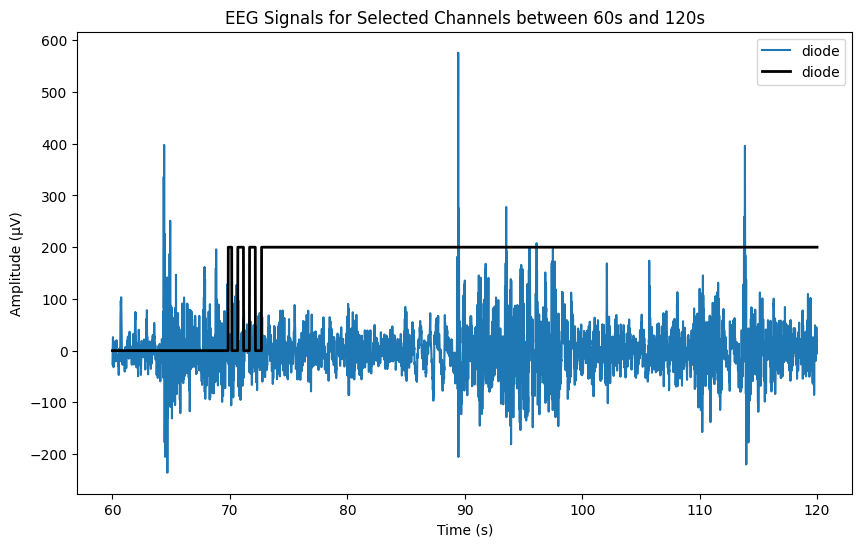

In [13]:
seleted_time = [60, 120]
# Get selected child EEG channels for specific time window
time, channels, data = multimodal_data.get_signals(
                mode='EEG', 
                member='ch', 
                selected_channels=['Fz', 'Cz', 'Pz'],
                selected_times=seleted_time
            )
time, channels, diode_data = multimodal_data.get_signals(
                mode='diode', 
                selected_channels=['diode'],
                selected_times=seleted_time
            )   
        
print(f"Retrieved EEG data shape: {data.shape}")  # Should be (n_channels, n_samples)
# Plot the retrieved EEG data
plt.figure(figsize=(10, 6))
for i, ch_name in enumerate(channels):
    plt.plot(time, data[:,i], label=ch_name)
plt.plot(time, diode_data[:,0]*200, label='diode', color='k', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title(f'EEG Signals for Selected Channels between {seleted_time[0]}s and {seleted_time[1]}s')
plt.legend()
plt.show()

## Select data using both time and event
- in this case we return the intersection of the time range and event range

Retrieved EEG data shape: (6419, 3)


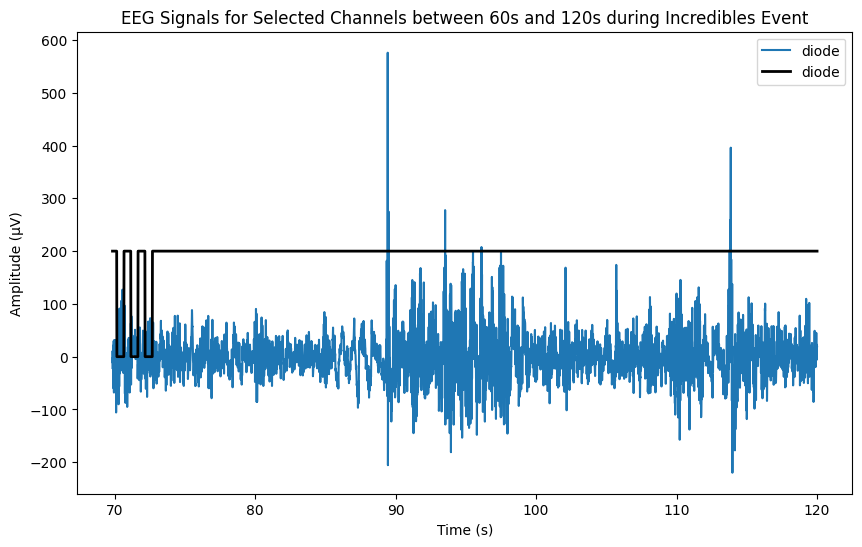

In [14]:
# Get selected child EEG channels for specific event and time window
seleted_time = [60, 120]
selected_event = 'Incredibles'
time, channels, data = multimodal_data.get_signals(
                mode='EEG', 
                member='ch', 
                selected_channels=['Fz', 'Cz', 'Pz'],
                selected_times=seleted_time,
                selected_events=[selected_event]
            )
time, channels, diode_data = multimodal_data.get_signals(
                mode='diode', 
                selected_channels=['diode'],
                selected_times=seleted_time,
                selected_events=[selected_event]
            )   
        
print(f"Retrieved EEG data shape: {data.shape}")  # Should be (n_channels, n_samples)
# Plot the retrieved EEG data
plt.figure(figsize=(10, 6))
for i, ch_name in enumerate(channels):
    plt.plot(time, data[:,i], label=ch_name)
plt.plot(time, diode_data[:,0]*200, label='diode', color='k', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title(f'EEG Signals for Selected Channels between {seleted_time[0]}s and {seleted_time[1]}s during {selected_event} Event')
plt.legend()
plt.show()

Event to marker mapping: {'Peppa': 1, 'Incredibles': 2, 'Brave': 3, 'Talk_1': 4, 'Talk_2': 5}


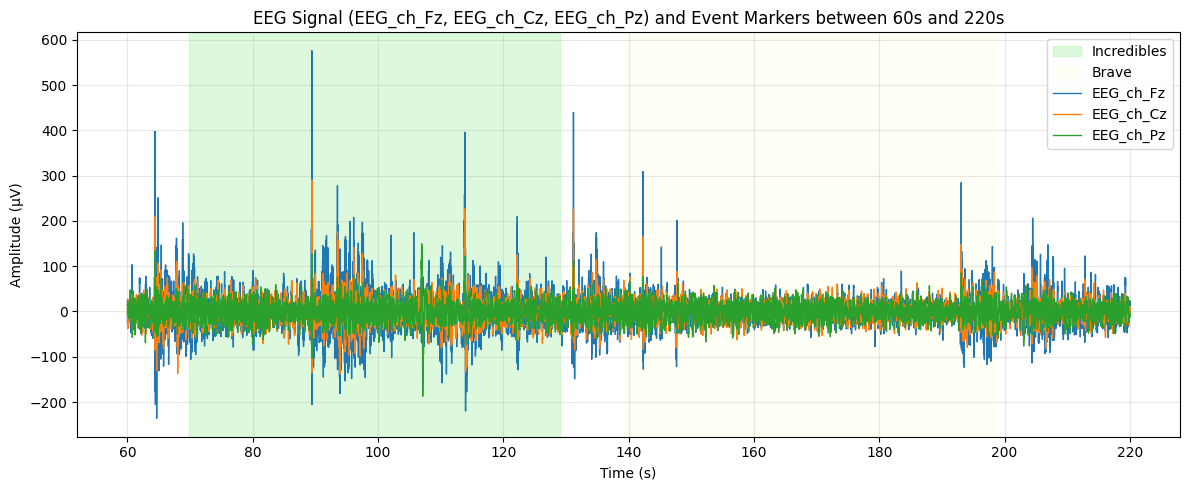

In [15]:
# Get selected child EEG channels for specific event and time window
seleted_time = [60, 220]
selected_event = 'Incredibles'
time, channels, data = multimodal_data.get_signals(
                mode='EEG', 
                member='ch', 
                selected_channels=['Fz', 'Cz', 'Pz'],
                selected_times=seleted_time
            )
time, marker_channel, event_to_marker = multimodal_data.get_events_as_marker_channel(selected_times=seleted_time)

print("Event to marker mapping:", event_to_marker)
utils.plot_signal_with_events(time, data,channels, marker_channel, event_to_marker, seleted_time)

## To select different typs of data we need to call the get_signals separately for each type


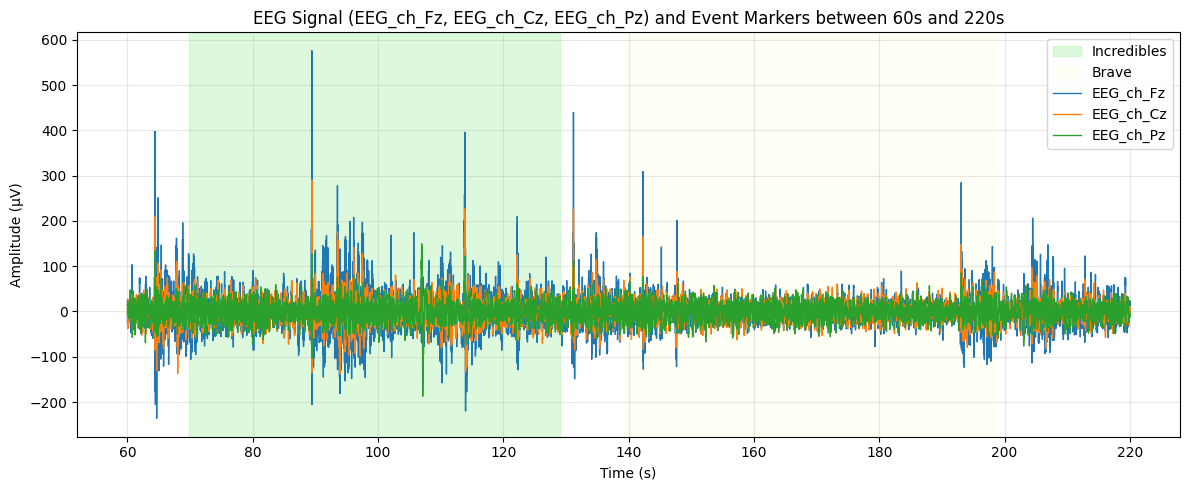

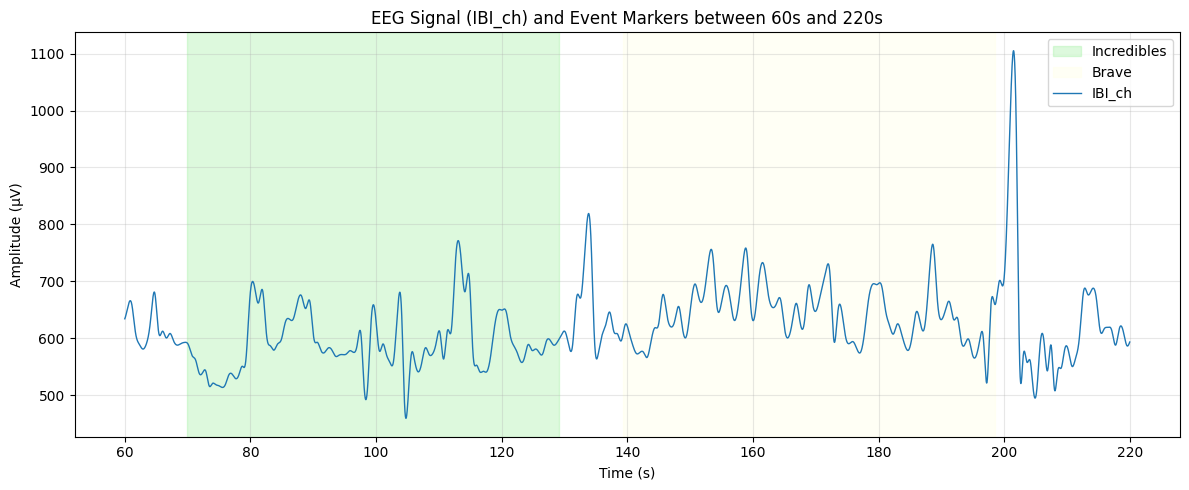

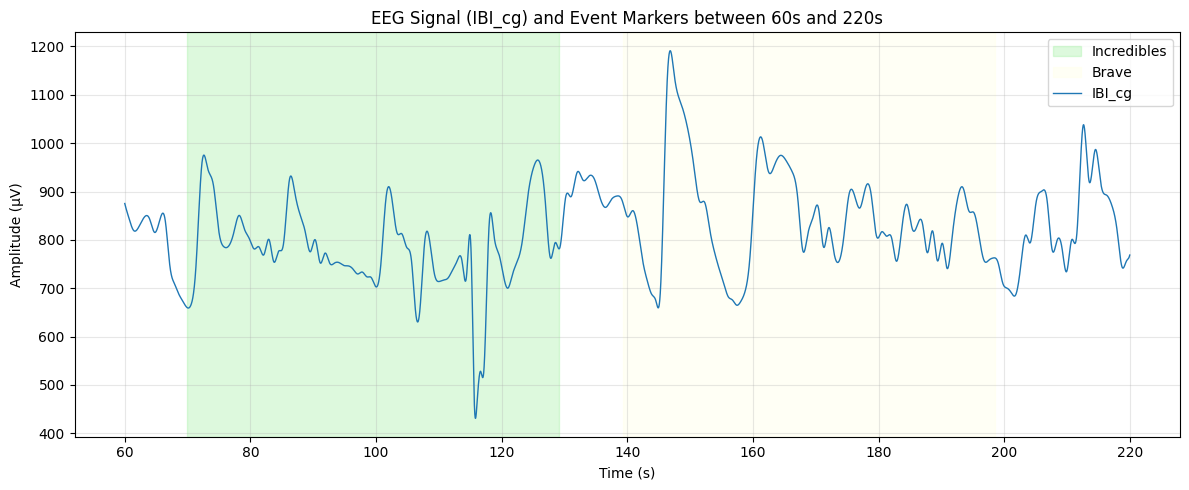

In [16]:
# Get selected child EEG channels for specific event and time window
seleted_time = [60, 220]
selected_event = 'Incredibles'
time, channels_EEG, data_EEG = multimodal_data.get_signals(
                mode='EEG', 
                member='ch', 
                selected_channels=['Fz', 'Cz', 'Pz'],
                selected_times=seleted_time
            )
time, channels_IBI_ch, data_IBI_ch = multimodal_data.get_signals(
                mode='IBI', 
                member='ch', 
                selected_channels=[''],
                selected_times=seleted_time
            )
time, channels_IBI_cg, data_IBI_cg = multimodal_data.get_signals(
                mode='IBI', 
                member='cg', 
                selected_channels=[''],
                selected_times=seleted_time
            )
time, marker_channel, event_to_marker = multimodal_data.get_events_as_marker_channel(selected_times=seleted_time)

utils.plot_signal_with_events(time, data_EEG,channels_EEG, marker_channel, event_to_marker, seleted_time)
utils.plot_signal_with_events(time, data_IBI_ch,channels_IBI_ch, marker_channel, event_to_marker, seleted_time)
utils.plot_signal_with_events(time, data_IBI_cg,channels_IBI_cg, marker_channel, event_to_marker, seleted_time)